                                   filename  execution_time  shrink_div_conq  \
0  data/SRS/Dataset_A/sig3_5_15/srs_156.txt         1.00461                0   
1  data/SRS/Dataset_A/sig3_5_15/srs_156.txt         0.79666                0   
2  data/SRS/Dataset_A/sig3_5_15/srs_156.txt         1.01873                0   
3  data/SRS/Dataset_A/sig3_5_15/srs_181.txt         2.02049                0   
4  data/SRS/Dataset_A/sig3_5_15/srs_181.txt         1.53580                0   

   expand_sw_size  expand_div_conq  shrink_sw_size  
0               1                1               5  
1               5                0               5  
2               1                0               5  
3               1                1               5  
4               5                0               5  
Index(['filename', 'execution_time', 'shrink_div_conq', 'expand_sw_size',
       'expand_div_conq', 'shrink_sw_size'],
      dtype='object')


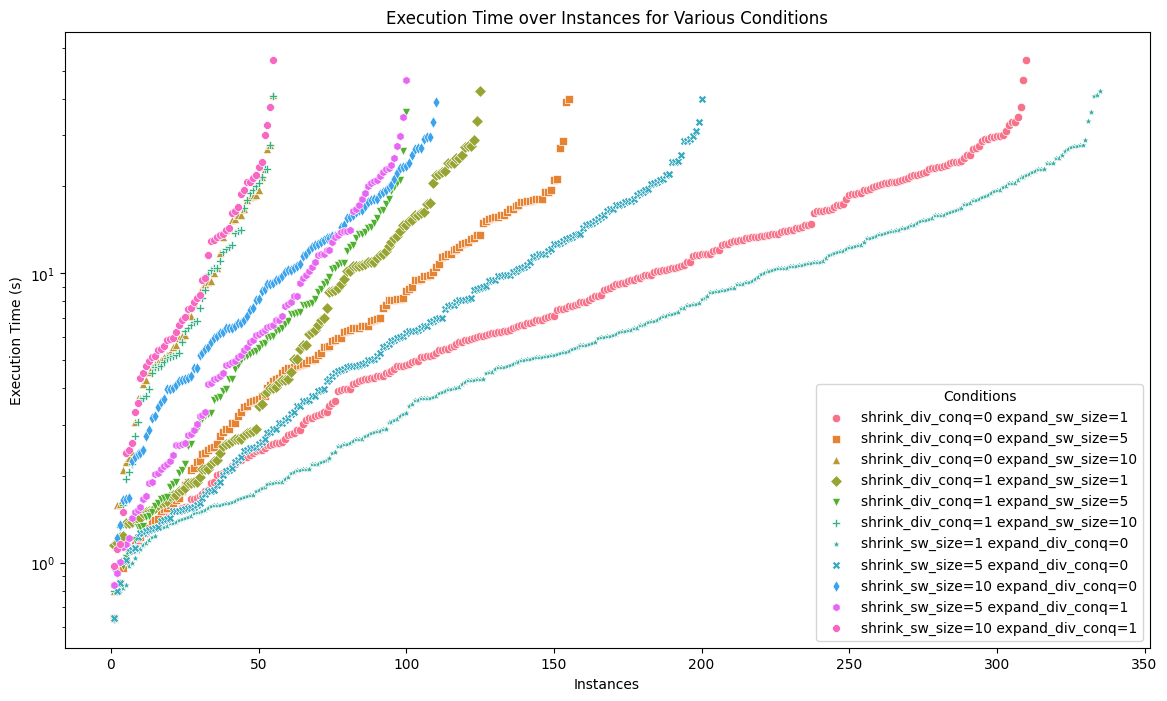

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file with the specified delimiter
df_divconq = pd.read_csv('240731_DIVCONQ.csv', delimiter=';')

# Print the first few rows to inspect the dataframe
print(df_divconq.head())
print(df_divconq.columns)

# Define the conditions for filtering
conditions = [
    {'shrink_div_conq': 0, 'expand_sw_size': 1},
    {'shrink_div_conq': 0, 'expand_sw_size': 5},
    {'shrink_div_conq': 0, 'expand_sw_size': 10},
    {'shrink_div_conq': 1, 'expand_sw_size': 1},
    {'shrink_div_conq': 1, 'expand_sw_size': 5},
    {'shrink_div_conq': 1, 'expand_sw_size': 10},
    {'shrink_sw_size': 1, 'expand_div_conq': 0},
    {'shrink_sw_size': 5, 'expand_div_conq': 0},
    {'shrink_sw_size': 10, 'expand_div_conq': 0},
    {'shrink_sw_size': 1, 'expand_div_conq': 1},
    {'shrink_sw_size': 5, 'expand_div_conq': 1},
    {'shrink_sw_size': 10, 'expand_div_conq': 1},
]

# Create a mapping for the conditions to different markers and colors
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'd', 'p', 'h', '8']
palette = sns.color_palette("husl", len(conditions))
labels = [f'shrink_div_conq={c.get("shrink_div_conq", "")} expand_sw_size={c.get("expand_sw_size", "")}' 
          if "shrink_div_conq" in c else 
          f'shrink_sw_size={c.get("shrink_sw_size", "")} expand_div_conq={c.get("expand_div_conq", "")}' 
          for c in conditions]

plt.figure(figsize=(14, 8))

# Plot each condition separately to apply different markers and colors
for i, condition in enumerate(conditions):
    subset = df_divconq
    for key, value in condition.items():
        subset = subset[subset[key] == value]
    
    if not subset.empty:
        # Sort the subset by execution_time
        subset = subset.sort_values(by='execution_time')
        # Create a counter for the x-axis based on the sorted order
        subset['counter'] = range(1, len(subset) + 1)
        
        # Plot the scatter points
        sns.scatterplot(
            x='counter', 
            y='execution_time', 
            data=subset,
            marker=markers[i], 
            color=palette[i], 
            label=labels[i]
        )

# Customize the plot
plt.title('Execution Time over Instances for Various Conditions')
plt.xlabel('Instances')
plt.ylabel('Execution Time (s)')
plt.legend(title='Conditions')
plt.yscale('log')

# Save or display the plot
plt.savefig('execution_time_over_conditions.png', dpi=300, bbox_inches='tight')
plt.show()


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the CSV file with the specified delimiter
df_divconq = pd.read_csv('240731_DIVCONQ.csv', delimiter=';')

# Print the first few rows to inspect the dataframe
print(df_divconq.head())
print(df_divconq.columns)

# Define the conditions for filtering
conditions = [
    {'shrink_div_conq': 0, 'expand_sw_size': 1},
    {'shrink_div_conq': 0, 'expand_sw_size': 5},
    {'shrink_div_conq': 0, 'expand_sw_size': 10},
    {'shrink_div_conq': 1, 'expand_sw_size': 1},
    {'shrink_div_conq': 1, 'expand_sw_size': 5},
    {'shrink_div_conq': 1, 'expand_sw_size': 10},
    {'shrink_sw_size': 1, 'expand_div_conq': 0},
    {'shrink_sw_size': 5, 'expand_div_conq': 0},
    {'shrink_sw_size': 10, 'expand_div_conq': 0},
    {'shrink_sw_size': 1, 'expand_div_conq': 1},
    {'shrink_sw_size': 5, 'expand_div_conq': 1},
    {'shrink_sw_size': 10, 'expand_div_conq': 1},
]

# Find common filenames that appear in all conditions
common_filenames = set(df_divconq['filename'])
for condition in conditions:
    subset = df_divconq
    for key, value in condition.items():
        subset = subset[subset[key] == value]
    common_filenames &= set(subset['filename'])

# Filter the dataframe to include only these common filenames
df_filtered = df_divconq[df_divconq['filename'].isin(common_filenames)]

# Create a mapping for the conditions to different markers and colors
markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'd', 'p', 'h', '8']
palette = sns.color_palette("husl", len(conditions))
labels = [f'shrink_div_conq={c.get("shrink_div_conq", "")} expand_sw_size={c.get("expand_sw_size", "")}' 
          if "shrink_div_conq" in c else 
          f'shrink_sw_size={c.get("shrink_sw_size", "")} expand_div_conq={c.get("expand_div_conq", "")}' 
          for c in conditions]

# Plot for each common filename
for filename in common_filenames:
    plt.figure(figsize=(14, 8))
    plt.title(f'Execution Time for {filename}')

    # Plot each condition separately for the current filename
    for i, condition in enumerate(conditions):
        subset = df_filtered[df_filtered['filename'] == filename]
        for key, value in condition.items():
            subset = subset[subset[key] == value]
        
        if not subset.empty:
            # Sort the subset by execution_time
            subset = subset.sort_values(by='execution_time')
            # Create a counter for the x-axis based on the sorted order
            subset['counter'] = range(1, len(subset) + 1)
            
            # Plot the scatter points
            sns.scatterplot(
                x='counter', 
                y='execution_time', 
                data=subset,
                marker=markers[i], 
                color=palette[i], 
                label=labels[i]
            )

    # Customize the plot
    plt.xlabel('Instances')
    plt.ylabel('Execution Time (s)')
    plt.legend(title='Conditions')
    plt.yscale('log')

    # Save or display the plot
    plt.savefig(f'execution_time_{filename.replace("/", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()


                                   filename  execution_time  shrink_div_conq  \
0  data/SRS/Dataset_A/sig3_5_15/srs_156.txt         1.00461                0   
1  data/SRS/Dataset_A/sig3_5_15/srs_156.txt         0.79666                0   
2  data/SRS/Dataset_A/sig3_5_15/srs_156.txt         1.01873                0   
3  data/SRS/Dataset_A/sig3_5_15/srs_181.txt         2.02049                0   
4  data/SRS/Dataset_A/sig3_5_15/srs_181.txt         1.53580                0   

   expand_sw_size  expand_div_conq  shrink_sw_size  
0               1                1               5  
1               5                0               5  
2               1                0               5  
3               1                1               5  
4               5                0               5  
Index(['filename', 'execution_time', 'shrink_div_conq', 'expand_sw_size',
       'expand_div_conq', 'shrink_sw_size'],
      dtype='object')
